In [2]:
import os
os.listdir()

['.DS_Store',
 'PhonePayIndia.csv',
 'PaytmIndia.csv',
 'sentiment_analysis.ipynb',
 '.ipynb_checkpoints',
 'venv',
 'GooglePayIndia.csv']

In [3]:
import pandas as pd

gpay = pd.read_csv("GooglePayIndia.csv")

phonepe = pd.read_csv("PhonePayIndia.csv")
paytm = pd.read_csv("PaytmIndia.csv")

In [5]:
gpay["app_name"] = "Google Pay"
phonepe["app_name"] = "PhonePe"
paytm["app_name"] = "Paytm"

In [6]:
print(gpay.columns)
print(phonepe.columns)
print(paytm.columns)

Index(['Unnamed: 0', 'reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'app_name'],
      dtype='object')
Index(['Unnamed: 0', 'reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'app_name'],
      dtype='object')
Index(['Unnamed: 0', 'reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'app_name'],
      dtype='object')


In [7]:
df = pd.concat([gpay, phonepe, paytm], ignore_index=True)

In [8]:
df.shape


(183876, 12)

In [9]:
df = df[['content', 'score', 'thumbsUpCount', 'at', 'app_name']]
df.head()

,content,score,thumbsUpCount,at,app_name
0,How do add a boarding pass? I see no passes tab.,1,0,2021-11-18 17:03:06,Google Pay
1,Best,5,0,2021-11-18 16:43:34,Google Pay
2,All ok,5,0,2021-11-18 16:12:42,Google Pay
3,"Rasy to use really... But there never, ever sh...",3,0,2021-11-18 16:06:35,Google Pay
4,I still do not understand why your restricting...,3,251,2021-11-18 15:48:08,Google Pay


In [10]:
df.isnull().sum()

content          12
score             0
thumbsUpCount     0
at                0
app_name          0
dtype: int64

In [11]:
df = df.dropna(subset=['content'])

In [12]:
df.shape

(183864, 5)

In [13]:
def map_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["score"].apply(map_sentiment)

In [14]:
df["sentiment"].value_counts()

sentiment
Positive    144490
Negative     32375
Neutral       6999
Name: count, dtype: int64

In [15]:
app_sentiment = pd.crosstab(df['app_name'], df['sentiment'])
app_sentiment

sentiment,Negative,Neutral,Positive
app_name,,,
Google Pay,10208,1928,22083
Paytm,20125,4554,113225
PhonePe,2042,517,9182


In [16]:
app_sentiment_pct = app_sentiment.div(app_sentiment.sum(axis=1), axis=0)
app_sentiment_pct

sentiment,Negative,Neutral,Positive
app_name,,,
Google Pay,0.298314,0.056343,0.645343
Paytm,0.145935,0.033023,0.821042
PhonePe,0.173920,0.044034,0.782046


Matplotlib is building the font cache; this may take a moment.


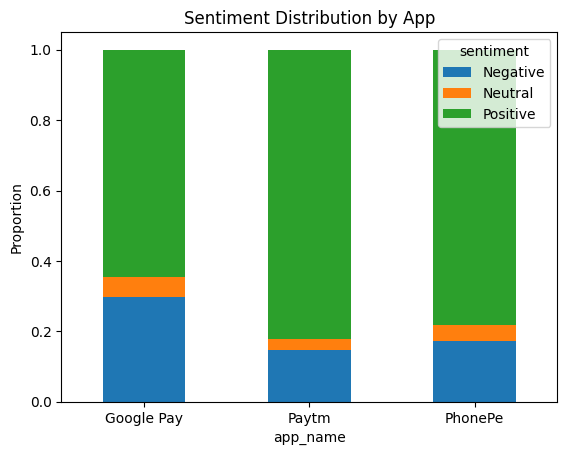

In [17]:
import matplotlib.pyplot as plt

app_sentiment_pct.plot(kind='bar', stacked=True)
plt.title("Sentiment Distribution by App")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

In [18]:
import re

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df["cleaned_text"] = df["content"].apply(clean_text)

In [19]:
df[["content", "cleaned_text"]].head()

,content,cleaned_text
0,How do add a boarding pass? I see no passes tab.,how do add a boarding pass i see no passes tab
1,Best,best
2,All ok,all ok
3,"Rasy to use really... But there never, ever sh...",rasy to use really but there never ever should...
4,I still do not understand why your restricting...,i still do not understand why your restricting...


In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [21]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [22]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [23]:
df.head()

,content,score,thumbsUpCount,at,app_name,sentiment,cleaned_text
0,How do add a boarding pass? I see no passes tab.,1,0,2021-11-18 17:03:06,Google Pay,Negative,how do add a boarding pass i see no passes tab
1,Best,5,0,2021-11-18 16:43:34,Google Pay,Positive,best
2,All ok,5,0,2021-11-18 16:12:42,Google Pay,Positive,all ok
3,"Rasy to use really... But there never, ever sh...",3,0,2021-11-18 16:06:35,Google Pay,Neutral,rasy to use really but there never ever should...
4,I still do not understand why your restricting...,3,251,2021-11-18 15:48:08,Google Pay,Neutral,i still do not understand why your restricting...


In [24]:
df["processed_text"] = df["cleaned_text"].apply(preprocess_text)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/Users/bhargabsonowal06/nltk_data'
    - '/Users/bhargabsonowal06/Documents/Data_projects/sentiment_analysis_project/venv/nltk_data'
    - '/Users/bhargabsonowal06/Documents/Data_projects/sentiment_analysis_project/venv/share/nltk_data'
    - '/Users/bhargabsonowal06/Documents/Data_projects/sentiment_analysis_project/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [25]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bhargabsonowal06/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bhargabsonowal06/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bhargabsonowal06/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bhargabsonowal06/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/bhargabsonowal06/nltk_data...


True

In [26]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [28]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [32]:
df["processed_text"] = df["cleaned_text"].apply(preprocess_text)

In [33]:
df[["cleaned_text", "processed_text"]].head()

,cleaned_text,processed_text
0,how do add a boarding pass i see no passes tab,add boarding pas see pass tab
1,best,best
2,all ok,ok
3,rasy to use really but there never ever should...,rasy use really never ever baddata among apps ...
4,i still do not understand why your restricting...,still understand restricting certain legal act...


In [34]:
df.head()

,content,score,thumbsUpCount,at,app_name,sentiment,cleaned_text,processed_text
0,How do add a boarding pass? I see no passes tab.,1,0,2021-11-18 17:03:06,Google Pay,Negative,how do add a boarding pass i see no passes tab,add boarding pas see pass tab
1,Best,5,0,2021-11-18 16:43:34,Google Pay,Positive,best,best
2,All ok,5,0,2021-11-18 16:12:42,Google Pay,Positive,all ok,ok
3,"Rasy to use really... But there never, ever sh...",3,0,2021-11-18 16:06:35,Google Pay,Neutral,rasy to use really but there never ever should...,rasy use really never ever baddata among apps ...
4,I still do not understand why your restricting...,3,251,2021-11-18 15:48:08,Google Pay,Neutral,i still do not understand why your restricting...,still understand restricting certain legal act...


In [35]:
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [37]:
X_train_tfidf.shape

(147091, 10000)

In [38]:
X_test_tfidf.shape

(36773, 10000)

In [39]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8820874010823159

Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.74      0.74      6475
     Neutral       0.12      0.00      0.00      1400
    Positive       0.91      0.96      0.93     28898

    accuracy                           0.88     36773
   macro avg       0.59      0.57      0.56     36773
weighted avg       0.85      0.88      0.86     36773



In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8875805618252522

Classification Report:

              precision    recall  f1-score   support

    Negative       0.80      0.70      0.75      6475
     Neutral       0.17      0.00      0.01      1400
    Positive       0.90      0.97      0.94     28898

    accuracy                           0.89     36773
   macro avg       0.63      0.56      0.56     36773
weighted avg       0.86      0.89      0.87     36773



In [41]:
lr_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model_balanced.fit(X_train_tfidf, y_train)

lr_bal_pred = lr_model_balanced.predict(X_test_tfidf)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, lr_bal_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_bal_pred))

Balanced Logistic Regression Accuracy: 0.8083104451635711

Classification Report:

              precision    recall  f1-score   support

    Negative       0.70      0.71      0.71      6475
     Neutral       0.09      0.22      0.12      1400
    Positive       0.93      0.86      0.89     28898

    accuracy                           0.81     36773
   macro avg       0.57      0.60      0.57     36773
weighted avg       0.86      0.81      0.83     36773



In [42]:
feature_names = tfidf.get_feature_names_out()

In [43]:
import numpy as np

coef = lr_model_balanced.coef_

In [44]:
def get_top_words(class_index, top_n=20):
    top_indices = np.argsort(coef[class_index])[-top_n:]
    return [feature_names[i] for i in top_indices]

print("Top Positive Words:\n", get_top_words(2))
print("\nTop Negative Words:\n", get_top_words(0))
print("\nTop Neutral Words:\n", get_top_words(1))

Top Positive Words:
 ['great experience', 'lovely', 'super fast', 'better new', 'easy pay', 'quick', 'comfortable', 'easy use', 'finally', 'fabulous', 'im happy', 'love google', 'easy set', 'easy', 'work well', 'smooth', 'way pay', 'brilliant', 'loved', 'convenient']

Top Negative Words:
 ['one star', 'trash', 'stopped working', 'wont let', 'amazon pay', 'cant', 'useless', 'uninstalling', 'rubbish', 'garbage', 'bakwas', 'scam', 'fake', 'suck', 'uninstalled', 'fraud', 'horrible', 'wrost', 'worst', 'waste']

Top Neutral Words:
 ['money one', 'opening app', 'say cant', 'still work', 'talk executive', 'app find', 'gpay phone', 'nz', 'ensure', 'lost rupee', 'time error', 'rectify', 'guide', 'cluttered', 'mistake', 'dont really', 'also good', 'also able', 'money others', 'google help']


In [45]:
negative_df = df[df["sentiment"] == "Negative"]

In [46]:
negative_df["app_name"].value_counts()

app_name
Paytm         20125
Google Pay    10208
PhonePe        2042
Name: count, dtype: int64

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_neg = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5)

X_neg = tfidf_neg.fit_transform(negative_df["processed_text"])
feature_names_neg = tfidf_neg.get_feature_names_out()

In [48]:
import numpy as np

word_scores = np.asarray(X_neg.mean(axis=0)).ravel()
top_indices = word_scores.argsort()[-20:]

top_negative_words = [feature_names_neg[i] for i in top_indices]
top_negative_words

['phone',
 'cant',
 'time',
 'dont',
 'customer',
 'account',
 'google',
 'payment',
 'work',
 'service',
 'pay',
 'use',
 'worst',
 'money',
 'card',
 'nice',
 'paytm',
 'bad',
 'good',
 'app']

In [49]:
for app in df["app_name"].unique():
    print("\nApp:", app)
    app_neg = df[(df["app_name"] == app) & (df["sentiment"] == "Negative")]
    
    tfidf_app = TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=5)
    X_app = tfidf_app.fit_transform(app_neg["processed_text"])
    
    feature_names_app = tfidf_app.get_feature_names_out()
    word_scores_app = np.asarray(X_app.mean(axis=0)).ravel()
    top_indices_app = word_scores_app.argsort()[-10:]
    
    top_words_app = [feature_names_app[i] for i in top_indices_app]
    print("Top Negative Words:", top_words_app)


App: Google Pay
Top Negative Words: ['google pay', 'doesnt', 'phone', 'cant', 'use', 'pay', 'google', 'work', 'card', 'app']

App: PhonePe
Top Negative Words: ['phonepe', 'phone', 'charge', 'recharge', 'money', 'worst', 'nice', 'bad', 'app', 'good']

App: Paytm
Top Negative Words: ['account', 'customer', 'money', 'service', 'worst', 'nice', 'paytm', 'bad', 'app', 'good']


In [50]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

svm_model = LinearSVC(class_weight='balanced')

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8652543986076741

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.70      0.73      6475
     Neutral       0.12      0.10      0.11      1400
    Positive       0.92      0.94      0.93     28898

    accuracy                           0.87     36773
   macro avg       0.60      0.58      0.59     36773
weighted avg       0.86      0.87      0.86     36773



In [51]:
df_binary = df[df["sentiment"] != "Neutral"].copy()

df_binary["binary_sentiment"] = df_binary["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

df_binary["binary_sentiment"].value_counts()

binary_sentiment
1    144490
0     32375
Name: count, dtype: int64

In [52]:
from sklearn.model_selection import train_test_split

X_bin = df_binary["processed_text"]
y_bin = df_binary["binary_sentiment"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin,
    y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bin = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5
)

X_train_bin_tfidf = tfidf_bin.fit_transform(X_train_bin)
X_test_bin_tfidf = tfidf_bin.transform(X_test_bin)

In [54]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

svm_bin = LinearSVC(class_weight='balanced')

svm_bin.fit(X_train_bin_tfidf, y_train_bin)

svm_bin_pred = svm_bin.predict(X_test_bin_tfidf)

print("Binary SVM Accuracy:", accuracy_score(y_test_bin, svm_bin_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_bin, svm_bin_pred))

Binary SVM Accuracy: 0.9010827467277301

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.79      0.75      6475
           1       0.95      0.93      0.94     28898

    accuracy                           0.90     35373
   macro avg       0.83      0.86      0.84     35373
weighted avg       0.91      0.90      0.90     35373



In [55]:
df.to_csv("data/processed/fintech_reviews_processed.csv", index=False)


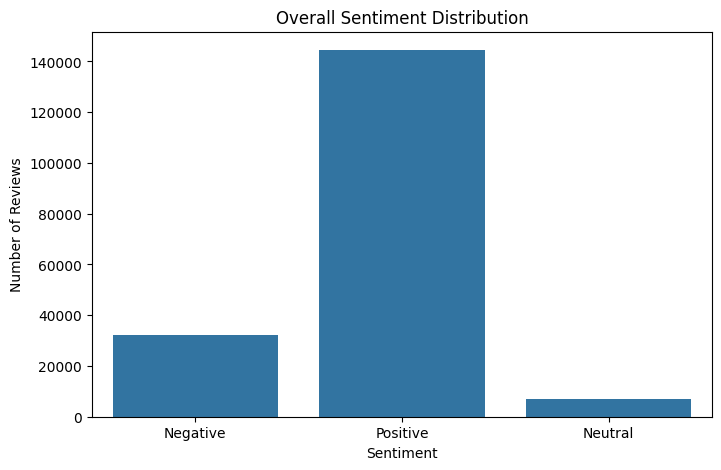

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x="sentiment", data=df)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("outputs/figures/sentiment_distribution.png")

plt.show()

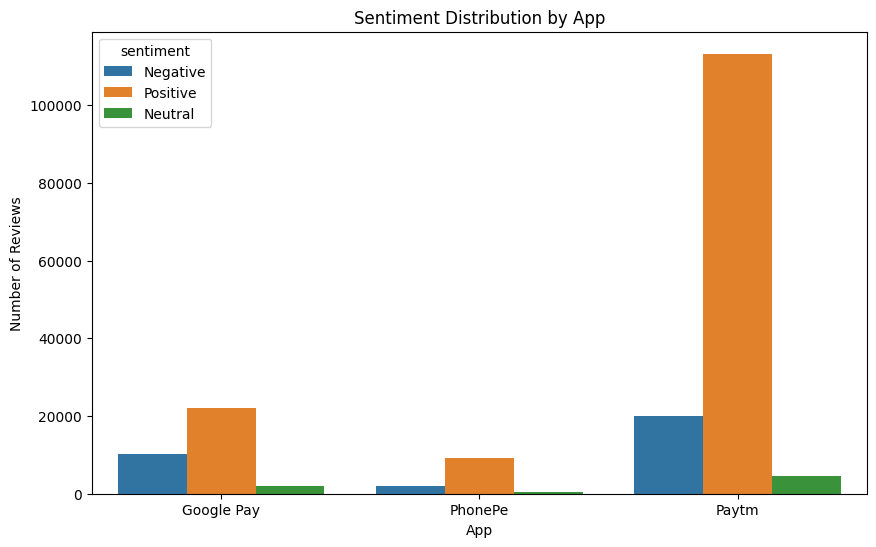

In [58]:
plt.figure(figsize=(10,6))

sns.countplot(x="app_name", hue="sentiment", data=df)

plt.title("Sentiment Distribution by App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")

plt.savefig("outputs/figures/sentiment_by_app.png")

plt.show()

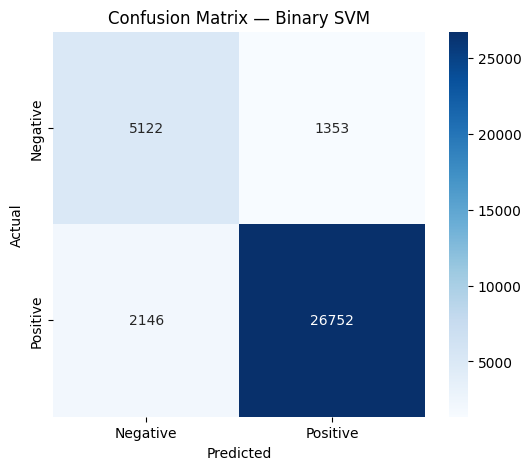

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_bin, svm_bin_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.title("Confusion Matrix — Binary SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("outputs/figures/confusion_matrix.png")

plt.show()

In [60]:
pip install wordcloud

     |████████████████████████████████| 168 kB 860 kB/s eta 0:00:01
You should consider upgrading via the '/Users/bhargabsonowal06/Documents/Data_projects/sentiment_analysis_project/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


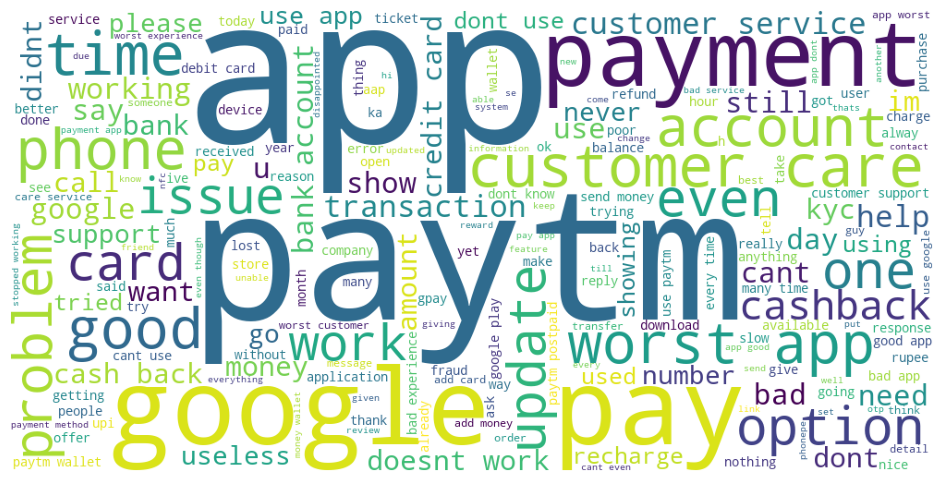

In [61]:
from wordcloud import WordCloud

negative_reviews = df[df["sentiment"] == "Negative"]["processed_text"]

text = " ".join(negative_reviews)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")

plt.savefig("outputs/figures/negative_wordcloud.png")

plt.show()